In [19]:
pip install blocksnet[ipynb]==1.0.0.a9 -q

In [20]:
!pip show blocksnet

Name: blocksnet
Version: 1.0.0a9
Summary: Package provides methods to autimatically generate master plan requirements for urban areas
Home-page: 
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: geopandas, iduedu, loguru, networkx, numpy, osmnx, pandas, pandera, PuLP, pyarrow, pydantic, scikit-learn, scipy, shapely, tqdm
Required-by: 


In [21]:
import pandas as pd
import geopandas as gpd

In [ ]:
boundaries = gpd.read_file('/content/sample_data/boundary.geojson')

In [ ]:
from blocksnet.relations import get_accessibility_graph

graph = get_accessibility_graph(boundaries, 'drive') # можно получить и другой тип графа,
                                                         # изменив graph_type на 'walk' или 'intermodal'

2026-02-07 22:16:51.726 | INFO     | iduedu.modules.drive_walk_builder:get_drive_graph_by_poly:91 - Downloading drive graph from OSM, it may take a while for large territory ...


In [ ]:
graph.to_pickle('graph_2.pickle')

AttributeError: 'MultiDiGraph' object has no attribute 'to_pickle'

In [ ]:
graph = pd.read_pickle('/content/graph.pickle')

In [22]:
left = gpd.read_file('/content/sample_data/blocks_with_services_gdf.geojson')

In [ ]:
from blocksnet.relations import calculate_accessibility_matrix

acc_mx = calculate_accessibility_matrix(left, graph)

ValueError: crs must be int

In [23]:
acc_mx.to_pickle('matrix.pickle')

In [24]:
import pandas as pd
matrix = pd.read_pickle('/content/matrix.pickle')

In [25]:
from blocksnet.analysis.provision import competitive_provision

Тайцы

In [ ]:
custom_config = {
    'school':       {'demand': 60,  'accessibility': 90},
    'kindergarten': {'demand': 40,  'accessibility': 30},
    'polyclinic':   {'demand': 15,  'accessibility': 180},
    'sport_centre':     {'demand': 1000,   'accessibility': 120},
    'music_school':     {'demand': 6,     'accessibility': 120},
    'cafe':             {'demand': 50,    'accessibility': 40},
    'post_office':      {'demand': 100,      'accessibility': 200},
    'supermarket':      {'demand': 486,   'accessibility': 30},
    'library':          {'demand': 10,      'accessibility': 200},
    'community_centre': {'demand': 10,      'accessibility': 200},
    'pharmacy':         {'demand': 50,    'accessibility': 20},
    'police':           {'demand': 1000,      'accessibility': 200},
    'fire_station':     {'demand': 1000,      'accessibility': 200},
    'park':             {'demand': 10000, 'accessibility': 10},
    'recreation':       {'demand': 2000,  'accessibility': 20},
    'parking':          {'demand': 20,    'accessibility': None},
    'cemetery':         {'demand': 300,  'accessibility': None},
    }

Кузьмолово

In [14]:
custom_config = {
    'school':       {'demand': 120,  'accessibility': 20},
    'kindergarten': {'demand': 61,  'accessibility': 10},
    'polyclinic':   {'demand': 15,  'accessibility': 180},
    'sport_centre':     {'demand': 10,   'accessibility': 60},
    'bus_stop':     {'demand': 20,     'accessibility': 10},
    'cafe':             {'demand': 50,    'accessibility': 40},
    'post_office':      {'demand': 100,      'accessibility': 200},
    'supermarket':      {'demand': 486,   'accessibility': 30},
    'library':          {'demand': 10,      'accessibility': 200},
    'community_centre': {'demand': 10,      'accessibility': 200},
    'pharmacy':         {'demand': 50,    'accessibility': 20},
    'police':           {'demand': 1000,      'accessibility': 200},
    'fire_station':     {'demand': 1000,      'accessibility': 200},
    'park':             {'demand': 150, 'accessibility': 30},
    'recreation':       {'demand': 2000,  'accessibility': 20},
    'parking':          {'demand': 100,    'accessibility': None},
    'cemetery':         {'demand': 300,  'accessibility': None},
    }

Шлиссельбург

In [26]:
custom_config = {
    'school':       {'demand': 120,  'accessibility': 20},
    'kindergarten': {'demand': 61,  'accessibility': 10},
    'polyclinic':   {'demand': 15,  'accessibility': 180},
    'sport_centre':     {'demand': 10,   'accessibility': 60},
    'bus_stop':     {'demand': 20,     'accessibility': 10},
    'cafe':             {'demand': 50,    'accessibility': 40},
    'post_office':      {'demand': 100,      'accessibility': 200},
    'supermarket':      {'demand': 486,   'accessibility': 30},
    'library':          {'demand': 10,      'accessibility': 200},
    'hotel':            {'demand': 10,      'accessibility': 60},
    'pharmacy':         {'demand': 50,    'accessibility': 20},
    'police':           {'demand': 1000,      'accessibility': 200},
    'fire_station':     {'demand': 1000,      'accessibility': 200},
    'park':             {'demand': 150, 'accessibility': 30},
    'recreation':       {'demand': 2000,  'accessibility': 20},
    'parking':          {'demand': 100,    'accessibility': None},
    'beach':       {'demand': 32,  'accessibility': 60},
    }

In [27]:
# Загрузка данных
blocks_gdf = gpd.read_file('/content/sample_data/blocks_with_services_gdf.geojson')
acc_mx = pd.read_pickle('matrix.pickle')

Отдельно каждый сервис

In [ ]:
# Выбор сервиса и получение параметров
service_type = 'library'
demand = custom_config[service_type]['demand']
accessibility = custom_config[service_type]['accessibility']

In [ ]:
# Подготовка и расчёт
df = blocks_gdf[['population', f'capacity_{service_type}']].rename(
    columns={f'capacity_{service_type}': 'capacity'}
)

prov_df, links_df = competitive_provision(df, acc_mx, accessibility, demand)

2026-01-25 15:53:48.711 | INFO     | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2026-01-25 15:53:48.713 | WARNING  | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2026-01-25 15:53:48.731 | INFO     | blocksnet.analysis.provision.competitive.core:_supply_self:56 - Supplying blocks with own capacities
2026-01-25 15:53:48.738 | INFO     | blocksnet.analysis.provision.competitive.core:competitive_provision:190 - Setting and solving LP problems until max depth or break condition reached
2026-01-25 15:53:48.755 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished


In [ ]:
# Сохранение
result = blocks_gdf[['geometry']].join(prov_df)
result.to_file('blocks_gdf.geojson', driver='GeoJSON')

<Axes: >

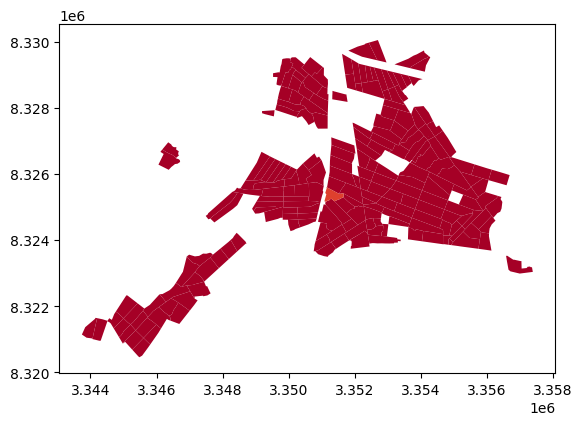

In [ ]:
blocks_gdf[['geometry']].join(prov_df).plot('provision_strong', vmin=0, vmax=1, cmap='RdYlGn')

Оценка всех сервисов сразу

In [28]:
# Максимальная доступность для сервисов без ограничений
max_accessibility = acc_mx.max().max()

In [29]:
# РЕЗУЛЬТИРУЮЩИЙ DATAFRAME (копия исходного)
# ============================================
result_gdf = blocks_gdf.copy()

In [30]:
# Словарь для хранения общих показателей
summary = {}

In [31]:
# ЦИКЛ ПО ВСЕМ СЕРВИСАМ
# ============================================
print("=" * 60)
print("ОЦЕНКА ОБЕСПЕЧЕННОСТИ ПО ВСЕМ СЕРВИСАМ")
print("=" * 60)

# ← ВОТ ЗДЕСЬ НАЧИНАЕТСЯ ЦИКЛ FOR
for service_type, params in custom_config.items():

    capacity_col = f'capacity_{service_type}'

    # Проверка наличия столбца с вместимостью
    if capacity_col not in blocks_gdf.columns:
        print(f"⚠️  {service_type:20} | столбец '{capacity_col}' не найден, пропуск")
        continue

    # ← ЭТА ЧАСТЬ ВНУТРИ ЦИКЛА (с отступом 4 пробела)
    # Получение параметров
    demand = params['demand']
    accessibility = params['accessibility']

    # Обработка None accessibility
    if accessibility is None:
        accessibility = max_accessibility
        acc_note = "(без огр.)"
    else:
        acc_note = f"{accessibility} мин"

    # Подготовка данных
    df = blocks_gdf[['population', capacity_col]].rename(
        columns={capacity_col: 'capacity'}
    )

    try:
        # Расчёт обеспеченности
        prov_df, links_df = competitive_provision(df, acc_mx, accessibility, demand)

        # Переименование колонок
        columns_to_add = {
            'demand': f'demand_{service_type}',
            'demand_left': f'demand_left_{service_type}',
            'demand_within': f'demand_within_{service_type}',
            'demand_without': f'demand_without_{service_type}',
            'capacity_left': f'capacity_left_{service_type}',
            'capacity_within': f'capacity_within_{service_type}',
            'capacity_without': f'capacity_without_{service_type}',
            'provision_strong': f'provision_strong_{service_type}',
            'provision_weak': f'provision_weak_{service_type}',
        }

        prov_df_renamed = prov_df.rename(columns=columns_to_add)

        # Присоединение к результату
        for col in prov_df_renamed.columns:
            result_gdf[col] = prov_df_renamed[col].values

        # Расчёт общих показателей
        total_demand = prov_df['demand'].sum()
        if total_demand > 0:
            p_strong = prov_df['demand_within'].sum() / total_demand
            p_weak = (prov_df['demand_within'].sum() + prov_df['demand_without'].sum()) / total_demand
        else:
            p_strong = p_weak = 0.0

        summary[service_type] = {
            'provision_strong': p_strong,
            'provision_weak': p_weak,
        }

        print(f"✅ {service_type:20} | Pstrong: {p_strong:.1%} | Pweak: {p_weak:.1%}")

    except Exception as e:
        print(f"❌ {service_type:20} | Ошибка: {e}")

2026-02-15 18:15:41.238 | INFO     | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2026-02-15 18:15:41.239 | WARNING  | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2026-02-15 18:15:41.258 | INFO     | blocksnet.analysis.provision.competitive.core:_supply_self:56 - Supplying blocks with own capacities
2026-02-15 18:15:41.262 | INFO     | blocksnet.analysis.provision.competitive.core:competitive_provision:190 - Setting and solving LP problems until max depth or break condition reached
2026-02-15 18:15:41.356 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
2026-02-15 18:15:41.369 | INFO     | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2026-02-15 18:15:41.371 | WARNING  | blocksnet.analysi

ОЦЕНКА ОБЕСПЕЧЕННОСТИ ПО ВСЕМ СЕРВИСАМ
✅ school               | Pstrong: 91.7% | Pweak: 91.7%


2026-02-15 18:15:41.475 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
2026-02-15 18:15:41.488 | INFO     | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2026-02-15 18:15:41.489 | WARNING  | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2026-02-15 18:15:41.503 | INFO     | blocksnet.analysis.provision.competitive.core:_supply_self:56 - Supplying blocks with own capacities
2026-02-15 18:15:41.509 | INFO     | blocksnet.analysis.provision.competitive.core:competitive_provision:190 - Setting and solving LP problems until max depth or break condition reached
2026-02-15 18:15:41.539 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
2026-02-15 18:15:41.552 | INFO     | blocksnet.analysis.pro

✅ kindergarten         | Pstrong: 90.9% | Pweak: 90.9%
✅ polyclinic           | Pstrong: 19.4% | Pweak: 19.4%
✅ sport_centre         | Pstrong: 2.0% | Pweak: 2.0%
⚠️  bus_stop             | столбец 'capacity_bus_stop' не найден, пропуск


2026-02-15 18:15:41.704 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
2026-02-15 18:15:41.716 | INFO     | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2026-02-15 18:15:41.717 | WARNING  | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2026-02-15 18:15:41.731 | INFO     | blocksnet.analysis.provision.competitive.core:_supply_self:56 - Supplying blocks with own capacities
2026-02-15 18:15:41.737 | INFO     | blocksnet.analysis.provision.competitive.core:competitive_provision:190 - Setting and solving LP problems until max depth or break condition reached
2026-02-15 18:15:41.753 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
2026-02-15 18:15:41.765 | INFO     | blocksnet.analysis.pro

...

2026-02-15 18:15:42.582 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: D

✅ park                 | Pstrong: 100.0% | Pweak: 100.0%
⚠️  recreation           | столбец 'capacity_recreation' не найден, пропуск


2026-02-15 18:15:42.895 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: D

✅ parking              | Pstrong: 100.0% | Pweak: 100.0%
✅ beach                | Pstrong: 100.0% | Pweak: 100.0%


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

In [32]:
# ИТОГОВАЯ СТАТИСТИКА
# ============================================
print("\n" + "=" * 60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("=" * 60)

# Создание сводной таблицы
summary_df = pd.DataFrame(summary).T
summary_df.index.name = 'service_type'
print(summary_df.to_string())


ИТОГОВАЯ СТАТИСТИКА
              provision_strong  provision_weak
service_type                                  
school                0.917008        0.917008
kindergarten          0.909193        0.909193
polyclinic            0.193798        0.193798
sport_centre          0.019704        0.019704
cafe                  0.237127        0.237127
post_office           0.000701        0.000701
supermarket           0.324819        0.324819
library               1.000000        1.000000
hotel                 1.000000        1.000000
pharmacy              0.325203        0.325203
police                0.004346        0.004346
fire_station          0.000072        0.000072
park                  1.000000        1.000000
parking               1.000000        1.000000
beach                 1.000000        1.000000


In [33]:
# Сохранение
result = blocks_gdf[['geometry']].join(prov_df)
result.to_file('blocks_gdf.geojson', driver='GeoJSON')

In [34]:
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================

# Сохранение полного результата
result_gdf.to_file('blocks_all_provision.geojson', driver='GeoJSON')
print(f"\n✅ Полный результат сохранён: 'blocks_all_provision.geojson'")
print(f"   Всего колонок: {len(result_gdf.columns)}")

# Сохранение сводной таблицы
summary_df.to_csv('provision_summary.csv')
print(f"✅ Сводка сохранена: 'provision_summary.csv'")


✅ Полный результат сохранён: 'blocks_all_provision.geojson'
   Всего колонок: 184
✅ Сводка сохранена: 'provision_summary.csv'


In [35]:
# ВЫВОД СПИСКА НОВЫХ КОЛОНОК
# ============================================
print("\n" + "=" * 60)
print("ДОБАВЛЕННЫЕ КОЛОНКИ ОБЕСПЕЧЕННОСТИ:")
print("=" * 60)

provision_cols = [col for col in result_gdf.columns if 'provision' in col]
for col in sorted(provision_cols):
    print(f"  • {col}")


ДОБАВЛЕННЫЕ КОЛОНКИ ОБЕСПЕЧЕННОСТИ:
  • provision_strong_beach
  • provision_strong_cafe
  • provision_strong_fire_station
  • provision_strong_hotel
  • provision_strong_kindergarten
  • provision_strong_library
  • provision_strong_park
  • provision_strong_parking
  • provision_strong_pharmacy
  • provision_strong_police
  • provision_strong_polyclinic
  • provision_strong_post_office
  • provision_strong_school
  • provision_strong_sport_centre
  • provision_strong_supermarket
  • provision_weak_beach
  • provision_weak_cafe
  • provision_weak_fire_station
  • provision_weak_hotel
  • provision_weak_kindergarten
  • provision_weak_library
  • provision_weak_park
  • provision_weak_parking
  • provision_weak_pharmacy
  • provision_weak_police
  • provision_weak_polyclinic
  • provision_weak_post_office
  • provision_weak_school
  • provision_weak_sport_centre
  • provision_weak_supermarket


In [ ]:
import matplotlib.pyplot as plt
import os

# Создаём папку для карт
output_dir = 'provision_maps'
os.makedirs(output_dir, exist_ok=True)

# Получаем список сервисов
provision_cols = [col for col in result_gdf.columns if col.startswith('provision_strong_')]
services = [col.replace('provision_strong_', '') for col in provision_cols]

# Создание карты для каждого сервиса
for service in services:
    col_strong = f'provision_strong_{service}'
    col_weak = f'provision_weak_{service}'

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Карта 1: Provision Strong
    ax1 = axes[0]
    result_gdf.plot(ax=ax1, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.1)
    result_gdf.plot(
        ax=ax1,
        column=col_strong,
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        legend=True,
        legend_kwds={'label': 'Обеспеченность', 'shrink': 0.7}
    )
    mean_strong = result_gdf[col_strong].mean()
    ax1.set_title(f'Provision Strong\nСреднее: {mean_strong:.1%}' if pd.notna(mean_strong) else 'Provision Strong', fontsize=12)
    ax1.set_axis_off()

    # Карта 2: Provision Weak
    ax2 = axes[1]
    result_gdf.plot(ax=ax2, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.1)
    result_gdf.plot(
        ax=ax2,
        column=col_weak,
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        legend=True,
        legend_kwds={'label': 'Обеспеченность', 'shrink': 0.7}
    )
    mean_weak = result_gdf[col_weak].mean()
    ax2.set_title(f'Provision Weak\nСреднее: {mean_weak:.1%}' if pd.notna(mean_weak) else 'Provision Weak', fontsize=12)
    ax2.set_axis_off()

    # Общий заголовок
    fig.suptitle(f'ОБЕСПЕЧЕННОСТЬ: {service.upper()}', fontsize=16, fontweight='bold')
    plt.tight_layout()

    # Сохранение
    filepath = os.path.join(output_dir, f'provision_{service}.png')
    plt.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()

    print(f"✅ Сохранено: {filepath}")

print(f"\n✅ Все карты сохранены в папку: '{output_dir}/'")

✅ Сохранено: provision_maps/provision_school.png
✅ Сохранено: provision_maps/provision_kindergarten.png
✅ Сохранено: provision_maps/provision_polyclinic.png
✅ Сохранено: provision_maps/provision_sport_centre.png
✅ Сохранено: provision_maps/provision_music_school.png
✅ Сохранено: provision_maps/provision_cafe.png
✅ Сохранено: provision_maps/provision_post_office.png
✅ Сохранено: provision_maps/provision_supermarket.png
✅ Сохранено: provision_maps/provision_library.png
✅ Сохранено: provision_maps/provision_community_centre.png
✅ Сохранено: provision_maps/provision_pharmacy.png
✅ Сохранено: provision_maps/provision_police.png
✅ Сохранено: provision_maps/provision_fire_station.png
✅ Сохранено: provision_maps/provision_park.png
✅ Сохранено: provision_maps/provision_recreation.png
✅ Сохранено: provision_maps/provision_parking.png
✅ Сохранено: provision_maps/provision_cemetery.png

✅ Все карты сохранены в папку: 'provision_maps/'
